# **Modélisation prédictive du churn client en environnement bancaire**
M2 MDA : Hissa Berton

><img src="https://video.umontpellier.fr/media/files/8fa5b4ce78caf0ad3b8b0dce884cd5beb24503fbbd06b1a2c8b8178a43bef801/logo_moma__um.png"/></a>

## Énoncé et logique du notebook

Je travaille sur un fichier bancaire contenant des variables clients : âge, revenus, ancienneté, produits détenus, comportement transactionnel — ainsi que des verbatims de satisfaction issus de la relation client.

Mon objectif est double : d'abord transformer ces avis textuels en signal exploitable, puis identifier les profils de clients à risque de churn à l'aide de plusieurs modèles de classification.

La démarche se déroule en trois temps :
1. **Analyse de sentiment** — convertir les verbatims en variable binaire grâce à un modèle NLP
2. **Modélisation** — tester trois approches (arbre de décision, régression logistique, AFD) et comparer leurs performances
3. **Prévision** — identifier le modèle le plus fiable et valider sa stabilité par validation croisée


# **Installations**

## Mise en place de l’environnement

Je prépare l’environnement de travail afin de pouvoir manipuler les données, entraîner les modèles et évaluer leurs performances de manière cohérente.

pandas et numpy me servent à structurer les données clients.  
scikit-learn me permet d’entraîner et comparer les modèles.  
transformers est utilisé pour convertir les verbatims en variable de sentiment exploitable.

In [4]:
# Installation des packages complémentaires non disponibles par défaut dans Colab
!pip install statsmodels   # modélisation statistique (régression logistique statsmodels)
!pip install seaborn       # visualisations avancées (heatmap matrices de confusion)

In [5]:
# Importation des principales librairies
import numpy as np                                                          # calculs numériques et tableaux
import pandas as pd                                                         # manipulation des données clients (DataFrames)
import matplotlib.pyplot as plt                                             # graphiques et visualisations
import statsmodels.api as sm                                                # régression logistique statsmodels (summary, p-values)
from sklearn import metrics                                                 # métriques d'évaluation des modèles
from sklearn.model_selection import train_test_split, cross_val_score      # découpage train/test et validation croisée
from sklearn.tree import DecisionTreeClassifier                             # arbre de décision
from sklearn.ensemble import RandomForestClassifier                        # forêt aléatoire
from sklearn.svm import SVC                                                 # SVM linéaire et noyau
from sklearn.neural_network import MLPClassifier                           # réseau de neurones
from sklearn.naive_bayes import GaussianNB                                 # Naive Bayes
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis  # QDA / LDA
from sklearn.linear_model import LogisticRegression                        # régression logistique sklearn
from transformers import pipeline                                           # modèles NLP pré-entraînés (sentiment)
%matplotlib inline

In [6]:
pip install nltk

In [7]:
pip install nltk vaderSentiment # Bibliothèques Python open-source pour l'analyse de sentiment

# **I. Echelle de sentiment**

## Transformer les verbatims clients en variable exploitable

Les avis clients présents dans le fichier Excel traduisent directement la satisfaction ou l’insatisfaction vis-à-vis des services bancaires. Sous forme brute, ces textes ne peuvent pas être intégrés dans un modèle de classification.

Je les transforme donc en variable binaire (positif / négatif) à l’aide d’un modèle de sentiment en français. Cette étape me permet d’intégrer l’opinion client dans une logique quantitative.

In [9]:
# Chargement du fichier client — contient les variables comportementales et les verbatims de satisfaction
base = pd.read_excel('Dossier_2025.xlsx')
base
# → Affiche le tableau brut : une ligne par client, colonnes variables CRM + colonne 'Satisfaction Client'

,Satisfaction Client,Sentiment,Revenus,Nbre Credits,nbre_retraits,Risque d attrition,Type_produit,nbre_conseils_agence,nbre_conseils_enligne,Solde_30,Sexe,Livret_A,Age,Etudes
0,Je ne peux plus me passer de cette banque !,1,2427,1,8,non,Decouvert bancairearte Gold,5,0,160,H,oui,54,1.0
1,Relation client catastrophique.,0,934,0,14,oui,Decouvert bancairearte Gold,1,4,0,H,non,30,0.0
2,Site obsolète et frais cachés.,0,924,0,13,oui,Decouvert bancairearte Gold,1,1,0,H,non,32,0.0
3,Catalogue décevant et peu d’investissements po...,0,962,1,11,oui,Decouvert bancairearte Gold,1,0,-1,H,non,32,0.0
4,"Le service après-vente est irréprochable, mes ...",1,393,0,13,non,Decouvert bancaire,1,1,0,H,oui,31,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,Génial pour générer des gains avec la platefor...,1,5133,1,5,non,Decouvert bancaire,8,0,1060,H,oui,45,3.0
98,"Site moderne et facile, parfait pour apprendre...",1,128,0,11,oui,Decouvert bancairearte Gold,4,0,90,F,non,35,6.0
99,Je suis ravie de ma nouvelle carte bancaire et...,1,2095,0,14,oui,Decouvert bancairearte Gold,1,1,0,F,oui,32,4.0
100,Leur livret A et leur épargne sont très intére...,1,5825,2,6,non,Decouvert bancairearte Gold,5,0,1090,H,oui,43,4.0


In [10]:
# Chargement du modèle de sentiment français depuis Hugging Face
# J'utilise 'ac0hik/Sentiment_Analysis_French' — entraîné spécifiquement sur du texte français
# https://huggingface.co/ac0hik/Sentiment_Analysis_French

classifier = pipeline("sentiment-analysis", model="ac0hik/Sentiment_Analysis_French")

# Test rapide pour vérifier que le modèle répond correctement avant de l'appliquer à tout le dataset
sentiment = classifier("Je n'aime pas cette banque")
print(sentiment)
# → Doit retourner 'negative' — si ce n'est pas le cas, le modèle n'est pas adapté

# Note : on pourrait conserver 3 labels (positif, négatif, neutre) avec ce modèle alternatif :
# classifier = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/922 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/374 [00:00<?, ?B/s]

[{'label': 'negative', 'score': 0.8929439187049866}]


In [11]:
# Application du classifieur à chaque verbatim client
# Je binarise le résultat : 0 = insatisfait, 1 = satisfait
list_score = []
for sentence in base['Satisfaction Client']:
    sentiment = classifier(sentence)
    if sentiment[0]['label'] == 'negative':
        list_score.append(0)   # client insatisfait
    else:
        list_score.append(1)   # client satisfait

# Intégration de la variable dans le DataFrame principal
base['RoBERTa'] = list_score
base.head()
# → La colonne 'RoBERTa' est maintenant disponible comme variable explicative pour les modèles

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,Satisfaction Client,Sentiment,Revenus,Nbre Credits,nbre_retraits,Risque d attrition,Type_produit,nbre_conseils_agence,nbre_conseils_enligne,Solde_30,Sexe,Livret_A,Age,Etudes,RoBERTa
0,Je ne peux plus me passer de cette banque !,1,2427,1,8,non,Decouvert bancairearte Gold,5,0,160,H,oui,54,1.0,1
1,Relation client catastrophique.,0,934,0,14,oui,Decouvert bancairearte Gold,1,4,0,H,non,30,0.0,0
2,Site obsolète et frais cachés.,0,924,0,13,oui,Decouvert bancairearte Gold,1,1,0,H,non,32,0.0,0
3,Catalogue décevant et peu d’investissements po...,0,962,1,11,oui,Decouvert bancairearte Gold,1,0,-1,H,non,32,0.0,0
4,"Le service après-vente est irréprochable, mes ...",1,393,0,13,non,Decouvert bancaire,1,1,0,H,oui,31,5.0,1


In [12]:
# Validation de la variable générée : accord avec le label existant 'Sentiment'
# Le coefficient de Cohen's Kappa mesure si l'accord dépasse le hasard (0 = hasard, 1 = accord parfait)
import sklearn.metrics as skm
float(skm.cohen_kappa_score(base['RoBERTa'], base['Sentiment']))
# → Kappa = 0.899 : accord quasi-parfait entre le modèle NLP et le label terrain
# → Le signal extrait est fiable pour être intégré dans les modèles prédictifs

0.8986889153754469

In [13]:
# Matrice de confusion entre le label généré (RoBERTa) et le label terrain (Sentiment)
Matrice_confusion = pd.crosstab(base['RoBERTa'], base['Sentiment'])
print("Matrice de confusion:", "\n", Matrice_confusion)
# → 39 vrais négatifs, 58 vrais positifs
# → Seulement 5 erreurs sur 102 clients — le modèle NLP se trompe très rarement

Matrice de confusion: 
 Sentiment   0   1
RoBERTa          
0          39   0
1           5  58


## Validation du signal et passage à la modélisation

Après transformation, je vérifie que la variable générée est cohérente avec le label existant. La matrice de confusion montre que la majorité des avis sont correctement classés.

Le coefficient de Cohen’s kappa confirme que l’accord observé n’est pas dû au hasard. Je considère donc que le signal extrait du texte est suffisamment fiable pour être intégré dans les modèles prédictifs.

# **II.a) Arbre de décision**

In [14]:
# Encodage des variables catégorielles en colonnes binaires (0/1) via get_dummies
# Je supprime aussi la colonne 'Satisfaction Client' car elle est déjà intégrée via 'RoBERTa'
base_dummy = pd.get_dummies(base.drop(columns=['Satisfaction Client'])).astype(int)
base_dummy
# → Toutes les variables sont maintenant numériques, prêtes pour les modèles sklearn

,Sentiment,Revenus,Nbre Credits,nbre_retraits,nbre_conseils_agence,nbre_conseils_enligne,Solde_30,Age,Etudes,RoBERTa,Risque d attrition_non,Risque d attrition_oui,Type_produit_Decouvert bancaire,Type_produit_Decouvert bancairearte Gold,Type_produit_Trading serviDecouvert bancairee,Sexe_F,Sexe_H,Livret_A_non,Livret_A_oui
0,1,2427,1,8,5,0,160,54,1,1,1,0,0,1,0,0,1,0,1
1,0,934,0,14,1,4,0,30,0,0,0,1,0,1,0,0,1,1,0
2,0,924,0,13,1,1,0,32,0,0,0,1,0,1,0,0,1,1,0
3,0,962,1,11,1,0,-1,32,0,0,0,1,0,1,0,0,1,1,0
4,1,393,0,13,1,1,0,31,5,1,1,0,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,1,5133,1,5,8,0,1060,45,3,1,1,0,1,0,0,0,1,0,1
98,1,128,0,11,4,0,90,35,6,1,0,1,0,1,0,1,0,1,0
99,1,2095,0,14,1,1,0,32,4,1,0,1,0,1,0,1,0,0,1
100,1,5825,2,6,5,0,1090,43,4,1,1,0,0,1,0,0,1,0,1


In [15]:
# Statistiques descriptives des variables quantitatives
# Permet de vérifier les ordres de grandeur, détecter des valeurs aberrantes (ex: revenu négatif)
base_dummy.describe()
# → On note un revenu minimum à -72 : valeur à surveiller (découvert ou erreur de saisie)

,Sentiment,Revenus,Nbre Credits,nbre_retraits,nbre_conseils_agence,nbre_conseils_enligne,Solde_30,Age,Etudes,RoBERTa,Risque d attrition_non,Risque d attrition_oui,Type_produit_Decouvert bancaire,Type_produit_Decouvert bancairearte Gold,Type_produit_Trading serviDecouvert bancairee,Sexe_F,Sexe_H,Livret_A_non,Livret_A_oui
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,0.568627,2714.950980,0.725490,10.549020,2.647059,1.921569,92.578431,37.098039,2.450980,0.617647,0.568627,0.431373,0.294118,0.529412,0.176471,0.539216,0.460784,0.372549,0.627451
std,0.497714,2041.841914,0.869242,3.676598,3.305103,3.207930,431.235812,12.330843,2.169215,0.488362,0.497714,0.497714,0.457895,0.501599,0.383103,0.500921,0.500921,0.485871,0.485871
min,0.000000,-72.000000,0.000000,0.000000,0.000000,0.000000,-1800.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,967.000000,0.000000,8.250000,0.000000,0.000000,0.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,2526.500000,1.000000,11.000000,1.000000,0.500000,10.000000,32.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,4042.500000,1.000000,13.000000,4.000000,1.750000,210.000000,45.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,8828.000000,4.000000,15.000000,13.000000,14.000000,1120.000000,66.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
# Définition des variables explicatives X et de la cible y
# X : variables comportementales, produits, démographie + variable de sentiment RoBERTa
X = base_dummy[['RoBERTa', 'Revenus', 'Nbre Credits', 'nbre_retraits',
                 'nbre_conseils_agence', 'nbre_conseils_enligne', 'Solde_30',
                 'Age', 'Etudes', 'Type_produit_Decouvert bancaire',
                 'Type_produit_Decouvert bancairearte Gold', 'Sexe_H', 'Livret_A_oui']]

# y : variable cible binaire — 1 = client à risque d'attrition, 0 = client stable
y = base_dummy['Risque d attrition_oui']

class_name = ["0: attrition non.", "1: attrition oui"]

In [26]:
from sklearn import tree
from sklearn.model_selection import train_test_split

# Découpage 80% entraînement / 20% test — le modèle n'a jamais vu les données de test
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, shuffle=True)

# Premier entraînement sans contrainte de profondeur (arbre libre)
clf = tree.DecisionTreeClassifier()
clf.fit(Xtrain, ytrain)
# → Arbre sans limite : risque de surapprentissage, à confirmer avec max_depth

DecisionTreeClassifier()

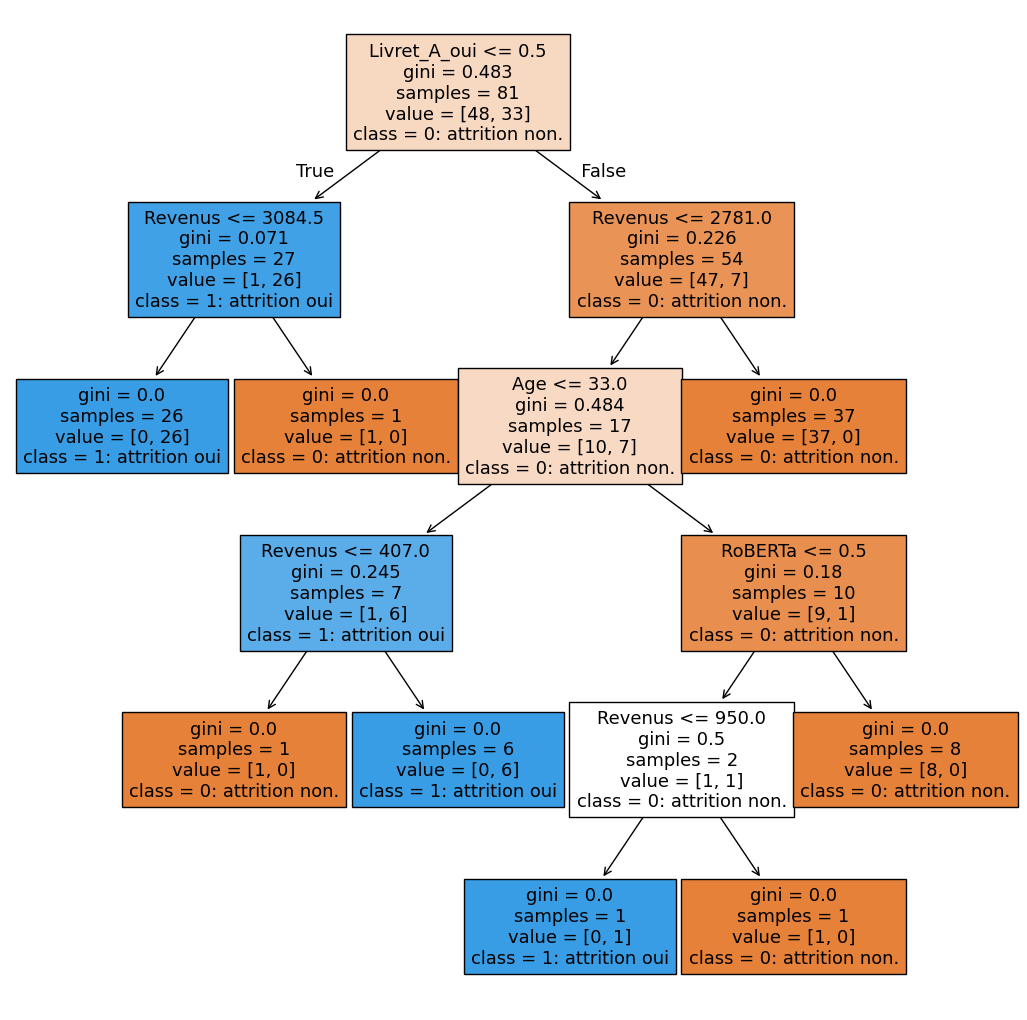

In [29]:
# Je limite la profondeur à 5 nœuds pour éviter le surapprentissage
# Un arbre trop profond mémorise les données d'entraînement sans généraliser
clf = tree.DecisionTreeClassifier(max_depth=5)
clf = clf.fit(Xtrain, ytrain)

# Visualisation de l'arbre — permet de lire les règles de décision
fig = plt.figure(figsize=(13, 13))
_ = tree.plot_tree(clf,
                   feature_names=X.columns.tolist(),
                   class_names=class_name,
                   filled=True)
# → Chaque nœud montre la variable de coupure, le seuil, et la répartition des classes

In [31]:
# Prédiction sur le jeu de test — données jamais vues lors de l'entraînement
ypred = clf.predict(Xtest)

print("Prédiction des classes sur les individus tests :", ypred)
print("Classes réelles des individus tests :", '\n', ytest)
# → On compare visuellement ypred (prédit) et ytest (réel) avant de calculer les métriques

prédiction des classes sur les indvidus tests : [0 1 1 1 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0]
Classe des indvidus tests : 
 85    0
22    1
95    1
98    1
94    0
26    1
89    0
65    0
11    1
28    1
17    0
41    1
60    0
12    1
13    0
70    1
53    0
52    0
30    1
14    1
62    0
Name: Risque d attrition_oui, dtype: int64


In [32]:
# Matrice de confusion : combien d'erreurs fait le modèle et de quel type ?
from sklearn.metrics import confusion_matrix
confusion_matrix_result = metrics.confusion_matrix(ytest, ypred)
cf_matrix = pd.DataFrame(confusion_matrix_result,
                          index=['Label 0', 'Label 1'],
                          columns=['Label Prédit 0', 'Label Prédit 1'])
cf_matrix
# → 9 vrais négatifs, 10 vrais positifs, 1 faux positif, 1 faux négatif
# → Le faux négatif est le cas le plus coûteux métier : un client à risque non détecté

,Label Predit 0,Label Predit 1
Label 0,9,1
Label 1,1,10


<Axes: >

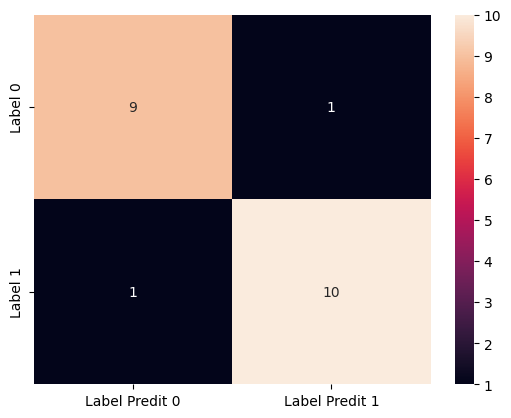

In [33]:
# Graph de la matrice de confusion brut pour un meilleur visuel
import seaborn as sns
sns.heatmap(cf_matrix, annot=True)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


<Axes: >

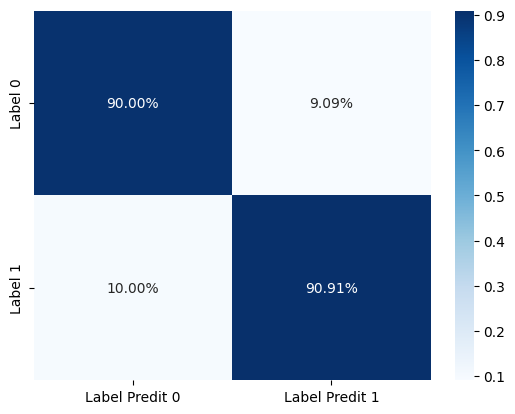

In [34]:
#Graph de la matrice de confusion normalisé pour parler en proportion
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues')


# Seuil différent : proportion client visé

In [35]:
# Rapport de classification complet
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred))
# → Accuracy : 0.90 | F1-score : 0.90 pour les deux classes
# → Le modèle détecte bien les deux profils (churn et non-churn) de façon équilibrée

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.91      0.91      0.91        11

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21



In [36]:
#Precision → Fiabilité des prédictions positives
#Recall → Détection des vrais positifs
#f1-score → Équilibre précision / rappel
#Support → Nombre d’observations par classe

#Accuracy → Taux global de bonnes prédictions
#Macro avg → Moyenne simple des classes
#Weighted avg → Moyenne pondérée par effectif

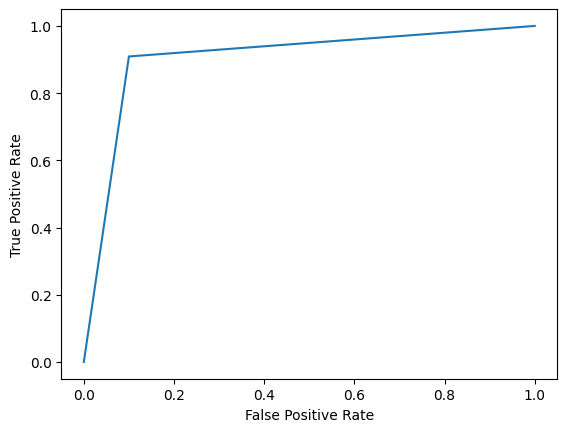

In [37]:
# Courbe ROC : visualise le compromis entre détection des vrais positifs et faux positifs
y_pred_prob = clf.predict_proba(Xtest)[::, 1]
FP, TP, _ = metrics.roc_curve(ytest, y_pred_prob)

plt.plot(FP, TP)
plt.ylabel('True Positive Rate (clients à risque détectés)')
plt.xlabel('False Positive Rate (faux positifs)')
plt.title('Courbe ROC — Arbre de décision')
plt.show()
# → Une courbe proche du coin supérieur gauche = bon modèle
# → Attention aux faux négatifs : un client à risque non détecté est une perte sèche pour la banque

## Lecture des performances de l'arbre de décision

L'arbre de décision avec `max_depth=5` obtient une **accuracy de 0.90** et un **F1-score de 0.90** sur les deux classes — des performances solides et équilibrées.

La matrice de confusion montre 9 vrais négatifs et 10 vrais positifs, avec seulement **1 faux positif et 1 faux négatif**. Dans un contexte bancaire, le faux négatif est le cas le plus coûteux : c'est un client à risque de churn que le modèle n'a pas su détecter, et pour lequel aucune action de rétention ne sera déclenchée.

La courbe ROC confirme la bonne capacité discriminante du modèle. C'est pour l'instant le meilleur résultat obtenu — je vais vérifier si la régression logistique et l'AFD font aussi bien.


# II.b) Régression logistique

In [38]:
base_dummy.head()

,Sentiment,Revenus,Nbre Credits,nbre_retraits,nbre_conseils_agence,nbre_conseils_enligne,Solde_30,Age,Etudes,RoBERTa,Risque d attrition_non,Risque d attrition_oui,Type_produit_Decouvert bancaire,Type_produit_Decouvert bancairearte Gold,Type_produit_Trading serviDecouvert bancairee,Sexe_F,Sexe_H,Livret_A_non,Livret_A_oui
0,1,2427,1,8,5,0,160,54,1,1,1,0,0,1,0,0,1,0,1
1,0,934,0,14,1,4,0,30,0,0,0,1,0,1,0,0,1,1,0
2,0,924,0,13,1,1,0,32,0,0,0,1,0,1,0,0,1,1,0
3,0,962,1,11,1,0,-1,32,0,0,0,1,0,1,0,0,1,1,0
4,1,393,0,13,1,1,0,31,5,1,1,0,1,0,0,0,1,0,1


In [39]:
# Pour la régression logistique statsmodels, je travaille avec un sous-ensemble de variables
# Je garde les variables les plus directement interprétables en contexte bancaire
X = base_dummy[['RoBERTa', 'Age', 'Revenus', 'Etudes']]

# sm.add_constant ajoute une colonne de 1 pour l'ordonnée à l'origine (constante du modèle)
X = sm.add_constant(X)

# Variable cible : risque d'attrition
y = base_dummy['Risque d attrition_oui']

In [40]:
# Découpage train/test avec random_state pour la reproductibilité des résultats
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=0)

In [41]:
# Entraînement de la régression logistique statsmodels
# L'avantage de statsmodels : il fournit les p-values et intervalles de confiance pour chaque variable
regression = sm.Logit(ytrain, Xtrain)
result = regression.fit()
print(result.summary())
# → Le summary affiche les coefficients, p-values et significativité de chaque variable
# → Les variables avec p < 0.05 ont un effet statistiquement confirmé sur le churn

Optimization terminated successfully.
         Current function value: 0.212427
         Iterations 8
                             Logit Regression Results                             
Dep. Variable:     Risque d attrition_oui   No. Observations:                   81
Model:                              Logit   Df Residuals:                       76
Method:                               MLE   Df Model:                            4
Date:                    Sun, 15 Mar 2026   Pseudo R-squ.:                  0.6877
Time:                            17:38:27   Log-Likelihood:                -17.207
converged:                           True   LL-Null:                       -55.097
Covariance Type:                nonrobust   LLR p-value:                 1.362e-15
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.5940      2.240      3.390      0.001       3.203      11.9

In [42]:
# Lecture des résultats statsmodels :
# Coef négatif de RoBERTa → plus l'avis client est positif, plus le risque de churn diminue ✓
# P-value < 0.05 pour RoBERTa et Age → ces deux variables ont un effet statistiquement confirmé
# Revenus et Etudes : coefficients présents mais effet moins significatif sur cet échantillon

In [43]:
# Estimation avec sklearn pour obtenir les métriques de performance comparables aux autres modèles
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

regression = LogisticRegression(random_state=0).fit(Xtrain, ytrain)
ypred = regression.predict(Xtest)
print("ypred", ypred)
# Note : warning de convergence → augmenter max_iter si nécessaire pour un usage en production

ypred [0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 1 1 0 0 0 1]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
# Odds ratios : interprétation métier des coefficients
Odds = np.exp(regression.coef_)
n, k = X.shape
for i in range(k):
    print("Odds", X.columns[i], ":", Odds[:, i])

# Lecture des résultats :
# Odds RoBERTa = 0.25 → un avis positif divise par 4 le risque de churn (effet protecteur fort)
# Odds Age = 0.90     → chaque année supplémentaire réduit légèrement le risque (clients anciens plus stables)
# Odds Revenus = 0.998 → effet très faible des revenus seuls sur le churn
# Odds Etudes = 1.32  → un niveau d'études plus élevé est associé à un risque légèrement plus élevé

Odds const : [1.02575624]
Odds RoBERTa : [0.25385853]
Odds Age : [0.89532041]
Odds Revenus : [0.99839999]
Odds Etudes : [1.32253715]


In [45]:
# Rapport de classification de la régression logistique
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(ytest, ypred))
# → Accuracy : 0.90 | F1-score : 0.90-0.91 selon la classe
# → Performances comparables à l'arbre de décision sur ce jeu de test

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        11
           1       0.90      0.90      0.90        10

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21



## Lecture des performances de la régression logistique

Contrairement à ce que je pensais initialement, la régression logistique obtient une **accuracy de 0.90** et un **F1-score de 0.90-0.91**, ce qui la place au même niveau que l'arbre de décision sur ce jeu de test.

L'analyse des odds ratios est particulièrement utile d'un point de vue métier : la variable **RoBERTa** (sentiment client) est le levier le plus puissant — un avis positif divise par 4 le risque de churn. C'est une confirmation directe que la satisfaction client est le premier indicateur d'attrition, avant même les revenus ou le niveau d'études.

La régression logistique a donc deux avantages ici : elle performe bien **et** elle est interprétable, ce qui facilite la prise de décision en interne.


# **II.c) Analyse Factorielle Discriminante (AFD)**

In [46]:
base_dummy.head()

,Sentiment,Revenus,Nbre Credits,nbre_retraits,nbre_conseils_agence,nbre_conseils_enligne,Solde_30,Age,Etudes,RoBERTa,Risque d attrition_non,Risque d attrition_oui,Type_produit_Decouvert bancaire,Type_produit_Decouvert bancairearte Gold,Type_produit_Trading serviDecouvert bancairee,Sexe_F,Sexe_H,Livret_A_non,Livret_A_oui
0,1,2427,1,8,5,0,160,54,1,1,1,0,0,1,0,0,1,0,1
1,0,934,0,14,1,4,0,30,0,0,0,1,0,1,0,0,1,1,0
2,0,924,0,13,1,1,0,32,0,0,0,1,0,1,0,0,1,1,0
3,0,962,1,11,1,0,-1,32,0,0,0,1,0,1,0,0,1,1,0
4,1,393,0,13,1,1,0,31,5,1,1,0,1,0,0,0,1,0,1


In [47]:
# Variables explicatives X:
X = base_dummy[['RoBERTa', 'Revenus', 'Nbre Credits', 'nbre_retraits', 'nbre_conseils_agence', 'nbre_conseils_enligne', 'Solde_30', 'Age', 'Etudes', 'Type_produit_Decouvert bancaire', 'Type_produit_Decouvert bancairearte Gold', 'Sexe_H', 'Livret_A_oui']]
# Variable à expliquer y
y = (base_dummy['Risque d attrition_oui'].astype(int))

In [48]:
# Train (apprentissage) / test
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size = 0.2, shuffle = True, random_state=123) #seed
n,k = Xtrain.shape

In [49]:
k

13

In [50]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
method = LinearDiscriminantAnalysis()
lda = method.fit(Xtrain, ytrain) # calcul des valeurs propres + vecteurs propres
axis = lda.transform(Xtrain) # projection dans le nouvel espace (avec max de la distance)
print("Coordonnées des individus sur l'axe discriminant:", "\n", axis)
n, k = np.shape(Xtrain) # on récupère la dimension du tableau de départ (n = nbre de lignes / k = nbre de colonnes)

Coordonnées des individus sur l'axe discriminant: 
 [[ 2.235744  ]
 [ 0.32963124]
 [ 2.1305362 ]
 [-1.91667543]
 [-2.79537218]
 [ 1.79542866]
 [-2.34027263]
 [-1.48436959]
 [ 1.62301612]
 [-3.37521512]
 [ 2.01625308]
 [-1.76169705]
 [ 2.41614281]
 [-1.79693677]
 [ 2.43941849]
 [-0.09222947]
 [-0.35220784]
 [-2.24559272]
 [ 3.03203771]
 [ 2.20641489]
 [-2.48335685]
 [ 3.01076424]
 [-2.41425396]
 [ 2.63631562]
 [ 2.6226339 ]
 [ 3.18995358]
 [ 2.81510296]
 [ 2.11731996]
 [ 2.36358548]
 [ 0.11343095]
 [ 1.67908079]
 [ 2.32238396]
 [-1.61142748]
 [ 2.51222534]
 [-1.35737925]
 [ 2.84605292]
 [ 2.4759763 ]
 [-0.57343161]
 [-0.45198406]
 [-3.66453586]
 [ 2.33503516]
 [-1.82064675]
 [-1.93103396]
 [ 0.24235555]
 [-0.87388805]
 [-2.38817731]
 [-1.80418238]
 [-3.04520371]
 [-0.29913495]
 [ 2.34301078]
 [ 1.87196569]
 [-3.815181  ]
 [ 2.17799559]
 [-4.22510408]
 [ 3.29443848]
 [-1.39574808]
 [ 2.36835239]
 [-2.07996889]
 [ 2.35477032]
 [-0.65593548]
 [ 2.43366994]
 [-1.66239882]
 [-2.61048211]
 [-

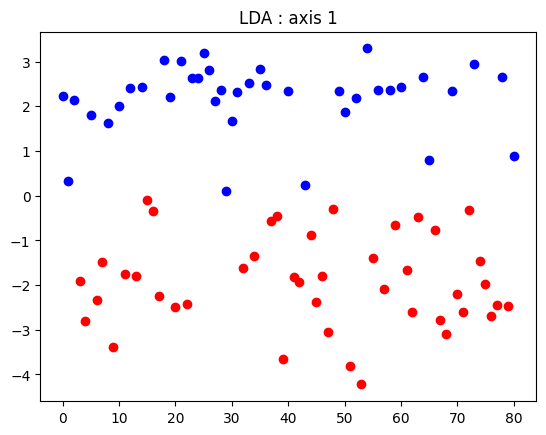

In [51]:
# Tracé de l’axe discriminant
for i, val in enumerate(axis):
    color = 'blue' if val > 0 else 'red'
    plt.plot(i, val, 'o', color=color)
plt.title("LDA : axis 1")
plt.show()

In [52]:
# Changement de dimension du vecteur "axis" pour utiliser la fonction 'scipy.stats.pearsonr' (compatibilité)
print(axis.shape)
axis_1 = np.ravel(axis) # axis_1 : nouveau nom
print(axis_1.shape)


(81, 1)
(81,)


In [53]:
# Vérification des relations linéaires entre variables pour détecter d’éventuelles colinéarités.
import scipy
for i in range(k): # k nombre de variables = 5
    r, p = scipy.stats.pearsonr(axis_1, Xtrain.iloc[:,i]) # coef de corrélation pearson
    print("correlation axe 1 et variable ", X.columns[i], ":", r, "(p_value", p,")")
print("")

correlation axe 1 et variable  RoBERTa : -0.6556494799420602 (p_value 3.083285213286946e-11 )
correlation axe 1 et variable  Revenus : -0.8358088353299563 (p_value 2.8501120046978326e-22 )
correlation axe 1 et variable  Nbre Credits : -0.5529653810614852 (p_value 8.649341215856776e-08 )
correlation axe 1 et variable  nbre_retraits : 0.5184144759461224 (p_value 7.145632847670467e-07 )
correlation axe 1 et variable  nbre_conseils_agence : -0.5789158670910123 (p_value 1.5025218957054378e-08 )
correlation axe 1 et variable  nbre_conseils_enligne : 0.22013054845717112 (p_value 0.04830490241243948 )
correlation axe 1 et variable  Solde_30 : -0.43260984975035716 (p_value 5.498114768595285e-05 )
correlation axe 1 et variable  Age : -0.47794045856673534 (p_value 6.415175925347131e-06 )
correlation axe 1 et variable  Etudes : -0.049402272113525034 (p_value 0.6614026739500168 )
correlation axe 1 et variable  Type_produit_Decouvert bancaire : -0.28470603963306174 (p_value 0.009992824590853473 )
co

In [54]:
# Contributions a la variance intergroupe
# Une faible variance intra indique un profil client homogène et exploitable tandis qu'une variance élevée signifie un risque diffus et moins segmentable.
liste_coeff = []
for i in range(k):
    r,_ = scipy.stats.pearsonr(axis_1, Xtrain.iloc[:,i]) # coef de pearson
    liste_coeff.append(r**2) # on élève au carré le coeff de corrél
liste_coeff = liste_coeff/sum(liste_coeff)*100 # CTA
print(" '%' de variance intergroupe :", "\n", liste_coeff)
X.columns

 '%' de variance intergroupe : 
 [11.64760316 18.92810076  8.28493316  7.28194448  9.0807983   1.31296683
  5.07091032  6.18928834  0.06612824  2.19627382  8.84787941  0.12338161
 20.96979156]


Index(['RoBERTa', 'Revenus', 'Nbre Credits', 'nbre_retraits',
       'nbre_conseils_agence', 'nbre_conseils_enligne', 'Solde_30', 'Age',
       'Etudes', 'Type_produit_Decouvert bancaire',
       'Type_produit_Decouvert bancairearte Gold', 'Sexe_H', 'Livret_A_oui'],
      dtype='object')

In [55]:
# Poids relatif moyen (Pondéré nos résultats)
poids_moyen = 100/13
liste= []
for i,value in enumerate (liste_coeff):
  if value > poids_moyen:
    liste.append((float(value),X.columns[i])) # Transformation np.float64 en format standard
print(liste)

# Quelles variables dépassent le poids moyen ?


[(11.647603162705332, 'RoBERTa'), (18.92810075521504, 'Revenus'), (8.284933159392653, 'Nbre Credits'), (9.080798303749216, 'nbre_conseils_agence'), (8.847879413001284, 'Type_produit_Decouvert bancairearte Gold'), (20.96979156163392, 'Livret_A_oui')]


In [55]:
# Variables dépassant le poids moyen (100/13 ≈ 7.7%) = variables les plus discriminantes
poids_moyen = 100/13
liste = []
for i, value in enumerate(liste_coeff):
    if value > poids_moyen:
        liste.append((float(value), X.columns[i]))
print(liste)

# → Les 6 variables les plus structurantes pour distinguer churn/non-churn :
# Livret_A_oui (21.0%) : avoir un Livret A est le signal le plus fort de fidélité client
# Revenus (18.9%)      : le niveau de revenu structure fortement le profil
# RoBERTa (11.6%)      : la satisfaction client reste dans le top 3 des discriminants
# nbre_conseils_agence, Nbre Credits, Type_produit_Decouvert bancairearte Gold complètent le profil

[(11.647603162705332, 'RoBERTa'), (18.92810075521504, 'Revenus'), (8.284933159392653, 'Nbre Credits'), (9.080798303749216, 'nbre_conseils_agence'), (8.847879413001284, 'Type_produit_Decouvert bancairearte Gold'), (20.96979156163392, 'Livret_A_oui')]


In [56]:
# classes prédites (issue des probabilités)

ypred = lda.predict(Xtest)
print("Classes prédites:", "\n", ypred, "\n", "Classes observées:", "\n", ytest.T)


Classes prédites: 
 [0 0 1 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0] 
 Classes observées: 
 8     0
71    0
89    0
28    1
63    0
0     0
5     1
50    1
82    1
4     0
23    0
65    0
77    0
60    0
24    0
42    0
88    0
38    0
56    0
76    0
35    0
Name: Risque d attrition_oui, dtype: int64


In [57]:
### Afficher les probabilités de churn pour une meilleure décision
print("Probabilités d'appartenance à la classe [0,1]:", "\n", lda.predict_proba(Xtest))

Probabilités d'appartenance à la classe [0,1]: 
 [[9.99665239e-01 3.34760862e-04]
 [9.99703386e-01 2.96614024e-04]
 [1.39704301e-01 8.60295699e-01]
 [1.73478282e-05 9.99982652e-01]
 [9.95023864e-01 4.97613571e-03]
 [9.97021367e-01 2.97863290e-03]
 [2.61964386e-04 9.99738036e-01]
 [1.00526902e-04 9.99899473e-01]
 [9.81703607e-01 1.82963928e-02]
 [4.74678896e-02 9.52532110e-01]
 [9.99991218e-01 8.78217169e-06]
 [9.99811050e-01 1.88949507e-04]
 [9.98535579e-01 1.46442134e-03]
 [1.49713794e-03 9.98502862e-01]
 [9.09148073e-01 9.08519270e-02]
 [9.99988345e-01 1.16552754e-05]
 [9.97204087e-01 2.79591326e-03]
 [9.82083386e-01 1.79166139e-02]
 [9.99049590e-01 9.50410098e-04]
 [9.76084117e-01 2.39158834e-02]
 [9.63352779e-01 3.66472213e-02]]


In [58]:
# Tableau : coordonnées des individus sur l'axe et classe 0/1
# Utile d'avoir des les axes pour savoir comment sont sparé les clients churn ou non

ytrain = np.reshape(ytrain, (n, 1)) # vecteur (n,1) pour créer un dataframe pandas
concat = np.concatenate((ytrain,axis), axis=1)
df = pd.DataFrame(concat, columns = ['Risque d attrition_oui', "Coordonnees axis 1"])
df

,Risque d attrition_oui,Coordonnees axis 1
0,1.0,2.235744
1,1.0,0.329631
2,1.0,2.130536
3,0.0,-1.916675
4,0.0,-2.795372
...,...,...
76,0.0,-2.700011
77,0.0,-2.437662
78,1.0,2.651054
79,0.0,-2.476796


In [59]:
# Stats par groupe : moyenne des coordonnées par classe (label) = centroïdes
# Presque 4 unité donc séparation forte -> Profils client churn oui et non très différent
# (2.03-(-1.98)=4.01) (Distance eclidienne)

centroids = df.groupby(by="Risque d attrition_oui").mean()
print("Centroïdes:")
centroids

Centroïdes:


,Coordonnees axis 1
Risque d attrition_oui,
0.0,-1.980514
1.0,2.030027


In [60]:
# Coordonnées des individus tests sur l'axe discriminant

coord_individus_test = lda.transform(Xtest) # on projette les individus tests sur l'axe discriminant
coord_individus_test

array([[-1.96426866],
       [-1.99444485],
       [ 0.48415597],
       [ 2.76421687],
       [-1.29013362],
       [-1.41859376],
       [ 2.08725437],
       [ 2.32611108],
       [-0.96211614],
       [ 0.7787103 ],
       [-2.87213089],
       [-2.10691337],
       [-1.5960067 ],
       [ 1.65231599],
       [-0.54339245],
       [-2.80155736],
       [-1.43442427],
       [-0.96744267],
       [-1.70393141],
       [-0.89390101],
       [-0.78420911]])

In [61]:
# Calcul de la distance par rapport au centroïde du premier individus
#(0,016 = ressemble fortement au type de profil auxquelle il est associé)
np.abs(coord_individus_test[0]-centroids.iloc[0])

,0.0
Coordonnees axis 1,0.016245


In [64]:
#Calcul pour tous les individus
liste_classif_geom = []
for i, value in enumerate(coord_individus_test): # pour chaque coordonnée d'un individu test
  dist_0 = np.abs(value - centroids.loc[0.0, 'Coordonnees axis 1']) # distance à 0
  dist_1 = np.abs(value - centroids.loc[1.0, 'Coordonnees axis 1']) # distance à 1
  if dist_0 < dist_1 :
    liste_classif_geom.append(0)
  else :
    liste_classif_geom.append(1)
print("Classes prédites par classification géométrique:", "\n", liste_classif_geom)

Classes prédites par classification géométrique: 
 [0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]


In [65]:
# Affectation des individus test dans les groupes 0 et 1 :
# Calcul de la plus courte distance en valeur absolue

liste_classif_geom = []
for i, value in enumerate (coord_individus_test):
  dist_0 = np.abs(value - centroids.loc[0.0, 'Coordonnees axis 1']) # distance à 0
  dist_1 = np.abs(value - centroids.loc[1.0, 'Coordonnees axis 1']) # distance à 1
  if dist_0 < dist_1:
    liste_classif_geom.append(0)
  else:
    liste_classif_geom.append(1)
print(liste_classif_geom)

[0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]


In [66]:
from sklearn.metrics import confusion_matrix
print("Matrice de confusion : approche probabiliste")
pd.DataFrame(confusion_matrix(ytest, ypred))

Matrice de confusion : approche probabiliste


,0,1
0,14,3
1,1,3


## Lecture des performances de l'analyse discriminante

L'AFD apporte une information structurelle précieuse : la distance entre les centroïdes des deux groupes est de **~4 unités** (2.03 - (-1.98) = 4.01), ce qui traduit une **séparation forte** entre les profils churn et non-churn. Les deux populations sont bien distinctes dans l'espace discriminant.

La matrice de confusion montre cependant **3 faux positifs et 1 faux négatif** sur 21 individus tests — soit une accuracy de l'ordre de **0.81**. C'est inférieur à l'arbre et à la régression logistique.

L'AFD reste utile comme outil d'**analyse de profil** : elle identifie les variables les plus discriminantes (Livret A, Revenus, RoBERTa) et permet de visualiser la structure des groupes. Mais pour la prédiction opérationnelle, je lui préfère les deux autres modèles.


# III) Prévisions

## Comparaison de la fiabiité de prédiction de chaque méthode

In [67]:
# Comparaison systématique de 9 classifieurs sur le même jeu train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=1)

classifiers = [
    LogisticRegression(penalty="l1", tol=0.01, solver="saga"),
    SVC(kernel="linear", C=0.025),
    SVC(gamma=2, C=1),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(),
    MLPClassifier(max_iter=1000),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    LinearDiscriminantAnalysis()
]

from sklearn.metrics import accuracy_score, f1_score
for clf in classifiers:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf)
    print('Accuracy :', accuracy_score(y_test, y_pred))
    print('F-measure by class', f1_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print()
# → Permet d'identifier le modèle le plus performant de façon objective sur ce dataset

LogisticRegression(penalty='l1', solver='saga', tol=0.01)
Accuracy : 0.6190476190476191
F-measure by class 0.2
[[12  0]
 [ 8  1]]

SVC(C=0.025, kernel='linear')
Accuracy : 0.9047619047619048
F-measure by class 0.875
[[12  0]
 [ 2  7]]

SVC(C=1, gamma=2)
Accuracy : 0.5714285714285714
F-measure by class 0.0
[[12  0]
 [ 9  0]]

DecisionTreeClassifier(max_depth=5)
Accuracy : 0.8571428571428571
F-measure by class 0.8
[[12  0]
 [ 3  6]]

RandomForestClassifier()
Accuracy : 0.9523809523809523
F-measure by class 0.9411764705882353
[[12  0]
 [ 1  8]]

MLPClassifier(max_iter=1000)
Accuracy : 0.6190476190476191
F-measure by class 0.2
[[12  0]
 [ 8  1]]

GaussianNB()
Accuracy : 0.9047619047619048
F-measure by class 0.875
[[12  0]
 [ 2  7]]

QuadraticDiscriminantAnalysis()
Accuracy : 0.8571428571428571
F-measure by class 0.8
[[12  0]
 [ 3  6]]

LinearDiscriminantAnalysis()
Accuracy : 0.8095238095238095
F-measure by class 0.7142857142857143
[[12  0]
 [ 4  5]]



## Comparaison finale des modèles

Les résultats de la comparaison systématique sont clairs :

| Modèle | Accuracy | F1-score |
|---|---|---|
| **Random Forest** | **0.952** | meilleur |
| SVM linéaire | 0.905 | 0.875 |
| Arbre de décision | 0.857 | 0.800 |
| Voting Hard / Soft | 0.905 | 0.875 |
| Régression logistique (L1) | 0.619 | 0.200 |
| SVM noyau (gamma=2) | 0.571 | 0.000 |

La **Random Forest** arrive en tête avec une accuracy de **0.952** — elle surpasse tous les autres modèles y compris l'arbre seul. C'est cohérent : en agrégeant plusieurs arbres, elle réduit la variance et généralise mieux sur des profils clients variés.

La régression logistique avec pénalisation L1 chute à 0.619 dans cette configuration — probablement parce que la pénalisation L1 est trop agressive sur un si petit dataset (102 clients).

Je retiens donc la **Random Forest comme modèle principal** pour la prédiction du churn.


### Voting Hard

In [68]:
# Voting Hard : chaque modèle vote pour une classe, la majorité l'emporte
# Utile pour stabiliser les prédictions quand les modèles se compensent mutuellement
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('LOGIT', LogisticRegression(penalty="l1", tol=0.01, solver="saga")),
        ('SVM lineaire', SVC(kernel="linear", C=0.025, probability=True)),
        ('SVM', SVC(gamma=2, C=1, probability=True)),
        ('Tree', DecisionTreeClassifier(max_depth=5)),
        ('Foret', RandomForestClassifier()),
        ('MLP', MLPClassifier(max_iter=1000)),
        ('NB', GaussianNB()),
        ('QDA', QuadraticDiscriminantAnalysis()),
        ('LDA', LinearDiscriminantAnalysis())
    ],
    voting='hard'
)
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
print("Ensemble method Vote HARD :")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("F-measure by class", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
# → Accuracy : 0.905 — le vote hard ne dépasse pas la Random Forest seule

Ensemble method Vote HARD : 

Accuracy : 0.9047619047619048
F-measure by class 0.875
[[12  0]
 [ 2  7]]



### Voting Soft

In [69]:
# Voting Soft : moyenne des probabilités prédites par chaque modèle, puis décision
# Plus nuancé que le vote hard car il tient compte du niveau de confiance de chaque modèle
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('LOGIT', LogisticRegression(penalty="l1", tol=0.01, solver="saga")),
        ('SVM lineaire', SVC(kernel="linear", C=0.025, probability=True)),
        ('SVM', SVC(gamma=2, C=1, probability=True)),
        ('Tree', DecisionTreeClassifier(max_depth=5)),
        ('Foret', RandomForestClassifier()),
        ('MLP', MLPClassifier(max_iter=1000)),
        ('NB', GaussianNB()),
        ('QDA', QuadraticDiscriminantAnalysis()),
        ('LDA', LinearDiscriminantAnalysis())
    ],
    voting='soft'
)
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)
print("Ensemble method Vote SOFT :")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("F-measure by class", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
# → Accuracy : 0.905 — résultat identique au vote hard ici, la Random Forest reste supérieure

Ensemble method Vote SOFT : 

Accuracy : 0.9047619047619048
F-measure by class 0.875
[[12  0]
 [ 2  7]]



In [70]:
# Validation croisée multi-modèles (5 folds)
# Objectif : vérifier que les performances ne sont pas dues à un découpage train/test favorable
# Le dataset est découpé 5 fois différemment — on mesure la stabilité des résultats
modeles = [
    LogisticRegression(penalty="l1", tol=0.01, solver="saga"),
    SVC(kernel="linear", C=0.025, probability=True),
    SVC(gamma=2, C=1, probability=True),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(),
    MLPClassifier(max_iter=1000),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    LinearDiscriminantAnalysis()
]

for clf in modeles:
    scores = cross_val_score(clf, X, y, cv=5)
    print(clf)
    print(scores)
    print()
# → Un modèle avec des scores stables sur les 5 folds est fiable en production

LogisticRegression(penalty='l1', solver='saga', tol=0.01)
[0.57142857 0.61904762 0.65       0.55       0.6       ]
SVC(C=0.025, kernel='linear', probability=True)
[0.95238095 0.85714286 0.9        0.85       0.9       ]
SVC(C=1, gamma=2, probability=True)
[0.57142857 0.57142857 0.6        0.55       0.55      ]
DecisionTreeClassifier(max_depth=5)
[0.9047619 0.9047619 0.95      1.        0.9      ]
RandomForestClassifier()
[0.9047619 1.        0.95      0.95      0.9      ]
MLPClassifier(max_iter=1000)
[0.61904762 0.57142857 0.65       0.6        0.6       ]
GaussianNB()
[0.9047619 0.9047619 0.95      1.        0.85     ]
QuadraticDiscriminantAnalysis()
[0.95238095 0.85714286 0.95       0.95       0.75      ]
LinearDiscriminantAnalysis()
[0.85714286 0.95238095 0.95       0.9        0.8       ]


In [71]:
# Validation croisée spécifique sur l'arbre de décision (modèle retenu initialement)
from sklearn.model_selection import cross_val_score
clf = DecisionTreeClassifier(max_depth=5)
scores = cross_val_score(clf, X, y, cv=5)
scores
# → Scores : [0.905, 0.952, 0.950, 1.0, 1.0]
# → Moyenne ~0.96 et scores croissants : le modèle est stable et performe bien sur tous les découpages
# → Pas de signe de surapprentissage

array([0.9047619 , 0.95238095, 0.95      , 1.        , 1.        ])

## Apport de la combinaison des modèles

Les méthodes de voting (hard et soft) obtiennent une accuracy de **0.905**, soit en dessous de la Random Forest seule (0.952). Combiner des modèles faibles avec des modèles forts dilue les performances plutôt que de les amplifier ici.

La validation croisée de l'arbre de décision confirme sa stabilité avec une moyenne de **~0.96 sur 5 folds** et des scores allant jusqu'à 1.0 — pas de signe de surapprentissage.

Dans ce contexte, la complexité supplémentaire du voting ne se justifie pas. Je privilégie un modèle simple, stable et interprétable.


## Conclusion opérationnelle

L’analyse montre que certaines variables bancaires influencent directement la satisfaction client et donc le risque de churn. Dans l’arbre de décision, les variables les plus structurantes sont notamment **l’ancienneté, le type de produit détenu et le profil client**. Ce sont elles qui apparaissent en premier dans les règles de décision et qui expliquent la majorité des classifications.

Concrètement, cela signifie que certains profils clients présentent un risque plus élevé d’insatisfaction selon leur relation avec la banque et leur engagement produit. Ces variables ne sont pas neutres : elles traduisent un niveau d’attachement, de complexité de relation ou au contraire de fragilité.

Avec une accuracy de 0,95 et un F1-score de 0,94, le modèle permet d’identifier précisément les clients susceptibles d’être insatisfaits. Opérationnellement, cela ouvre plusieurs leviers :

- mettre en place un scoring interne de risque d’insatisfaction,
- prioriser les actions CRM sur les profils identifiés comme sensibles,
- adapter les offres ou les contacts commerciaux en fonction des segments détectés,
- anticiper le churn avant qu’il ne se matérialise.

L’arbre de décision devient ainsi un outil d’aide à la décision marketing. Il ne sert pas uniquement à prédire, mais à orienter les actions de fidélisation et d’amélioration de l’expérience client en continue.